In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "data.csv"

df = pd.read_csv(DATA_PATH, sep=";")

df.head()

,Melt temperature,Mold temperature,time_to_fill,ZDx - Plasticizing time,ZUx - Cycle time,SKx - Closing force,SKs - Clamping force peak value,Ms - Torque peak value current cycle,Mm - Torque mean value current cycle,APSs - Specific back pressure peak value,APVs - Specific injection pressure peak value,CPn - Screw position at the end of hold pressure,SVo - Shot volume,quality
0,106.476184,80.617,7.124,3.16,74.83,886.900000,904.000000,116.9,104.300000,145.6,922.3,8.82,18.73,1.0
1,105.505000,81.362,6.968,3.16,74.81,919.409791,935.900000,113.9,104.900000,145.6,930.5,8.59,18.73,1.0
2,105.505000,80.411,6.864,4.08,74.81,908.600000,902.344823,120.5,106.503496,147.0,933.1,8.80,18.98,1.0
3,106.474827,81.162,6.864,3.16,74.82,879.410871,902.033653,127.3,104.900000,145.6,922.3,8.85,18.73,1.0
4,106.466140,81.471,6.864,3.22,74.83,885.644260,902.821269,120.5,106.700000,145.6,917.5,8.80,18.75,1.0


In [ ]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)


Dataset shape: (1451, 14)

Column names:
['Melt temperature', 'Mold temperature', 'time_to_fill', 'ZDx - Plasticizing time', 'ZUx - Cycle time', 'SKx - Closing force', 'SKs - Clamping force peak value', 'Ms - Torque peak value current cycle', 'Mm - Torque mean value current cycle', 'APSs - Specific back pressure peak value', 'APVs - Specific injection pressure peak value', 'CPn - Screw position at the end of hold pressure', 'SVo - Shot volume', 'quality']

Data types:
Melt temperature                                    float64
Mold temperature                                    float64
time_to_fill                                        float64
ZDx - Plasticizing time                             float64
ZUx - Cycle time                                    float64
SKx - Closing force                                 float64
SKs - Clamping force peak value                     float64
Ms - Torque peak value current cycle                float64
Mm - Torque mean value current cycle           

In [4]:
df.isnull().sum()

Melt temperature                                    0
Mold temperature                                    0
time_to_fill                                        0
ZDx - Plasticizing time                             0
ZUx - Cycle time                                    0
SKx - Closing force                                 0
SKs - Clamping force peak value                     0
Ms - Torque peak value current cycle                0
Mm - Torque mean value current cycle                0
APSs - Specific back pressure peak value            0
APVs - Specific injection pressure peak value       0
CPn - Screw position at the end of hold pressure    0
SVo - Shot volume                                   0
quality                                             0
dtype: int64

In [5]:
print(df["quality"].value_counts().sort_index())

quality
1.0    370
2.0    406
3.0    310
4.0    365
Name: count, dtype: int64


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Melt temperature,1451.0,106.892040,5.615773,81.747,105.9145,106.0890,106.263000,155.032
Mold temperature,1451.0,81.326023,0.428813,78.409,81.1235,81.3270,81.441000,82.159
time_to_fill,1451.0,7.459043,1.688106,6.084,6.2920,6.9680,7.124000,11.232
ZDx - Plasticizing time,1451.0,3.234173,0.343230,2.780,3.0000,3.1926,3.290000,6.610
ZUx - Cycle time,1451.0,75.218794,0.432761,74.780,74.8200,74.8300,75.650000,75.790
SKx - Closing force,1451.0,901.974834,11.098192,876.700,893.6000,902.4000,909.400000,930.600
SKs - Clamping force peak value,1451.0,919.351778,10.780023,894.800,914.4000,918.8000,926.300000,946.500
Ms - Torque peak value current cycle,1451.0,116.716747,5.029085,94.200,114.2000,116.9000,120.200000,130.300
Mm - Torque mean value current cycle,1451.0,104.163904,4.802195,76.500,103.5500,105.2000,106.531415,114.900
APSs - Specific back pressure peak value,1451.0,146.230048,0.804894,144.800,145.6000,146.1000,146.700000,150.500


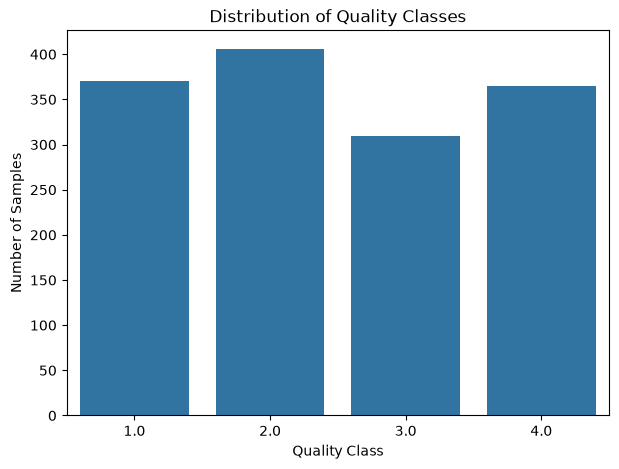

In [7]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="quality"
)

plt.title("Distribution of Quality Classes")
plt.xlabel("Quality Class")
plt.ylabel("Number of Samples")

plt.show()

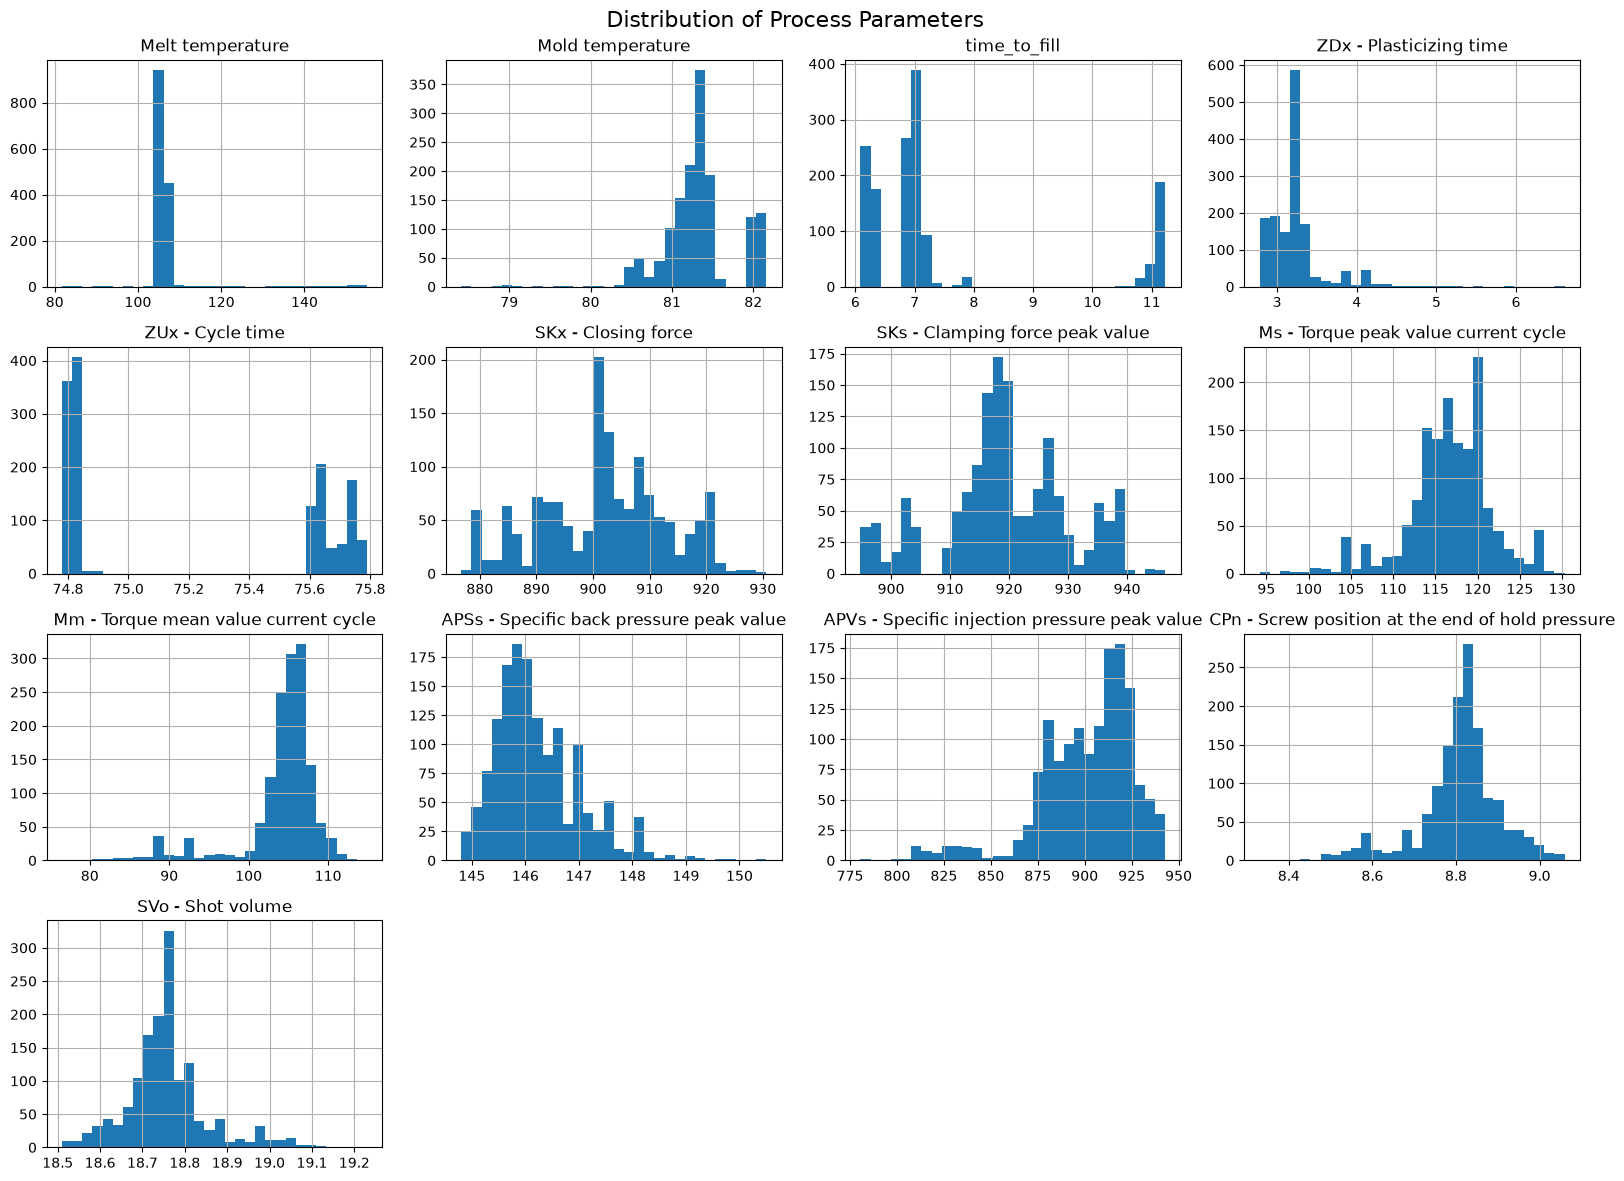

In [8]:
df.drop(columns=["quality"]).hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle("Distribution of Process Parameters", fontsize=16)

plt.tight_layout()
plt.show()

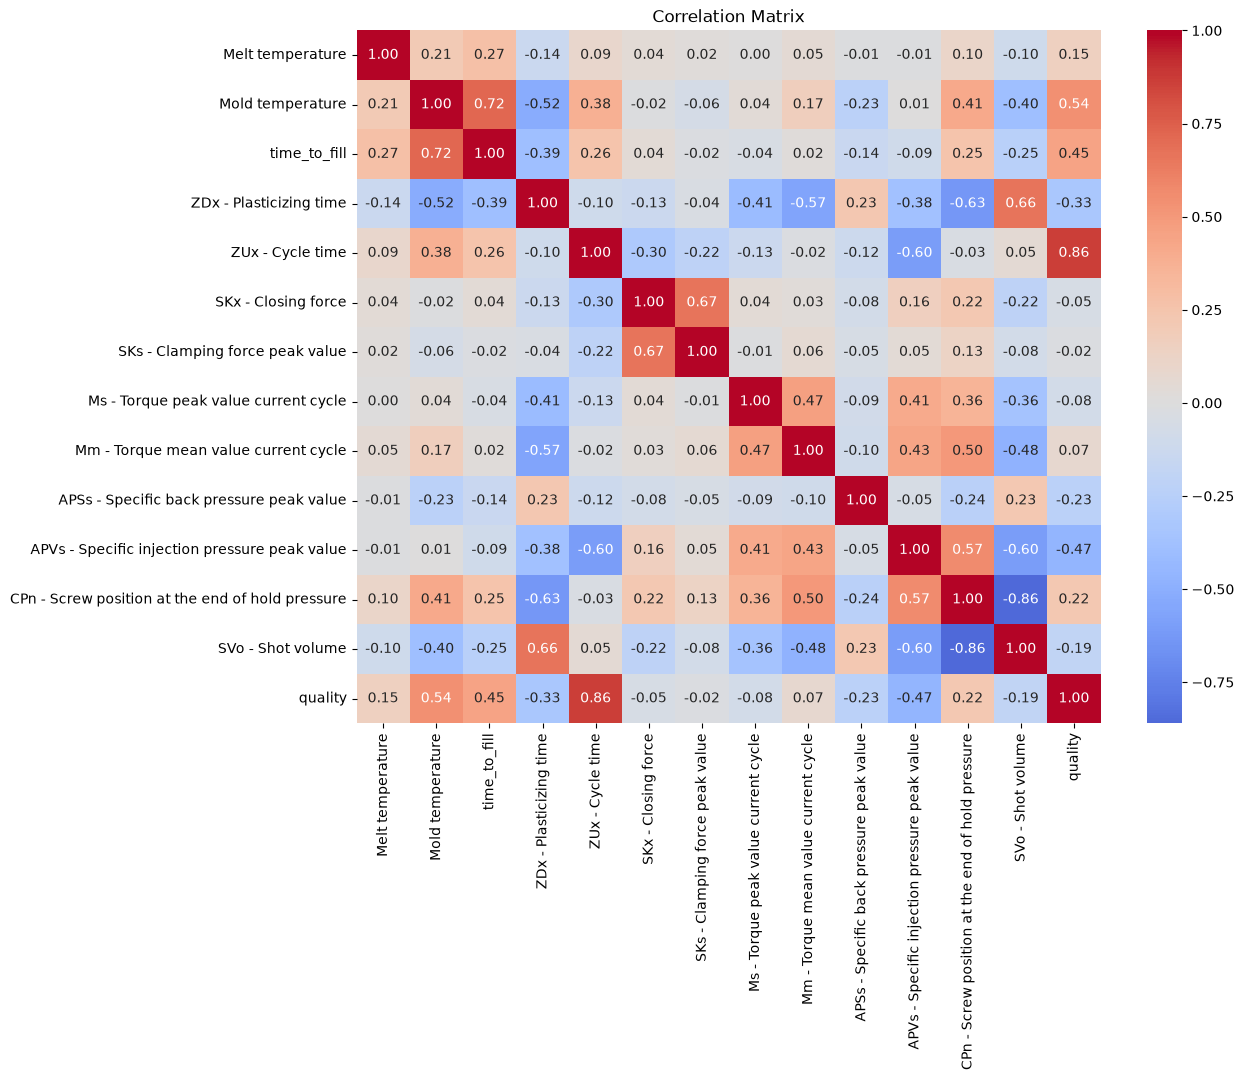

In [9]:
plt.figure(figsize=(12, 9))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

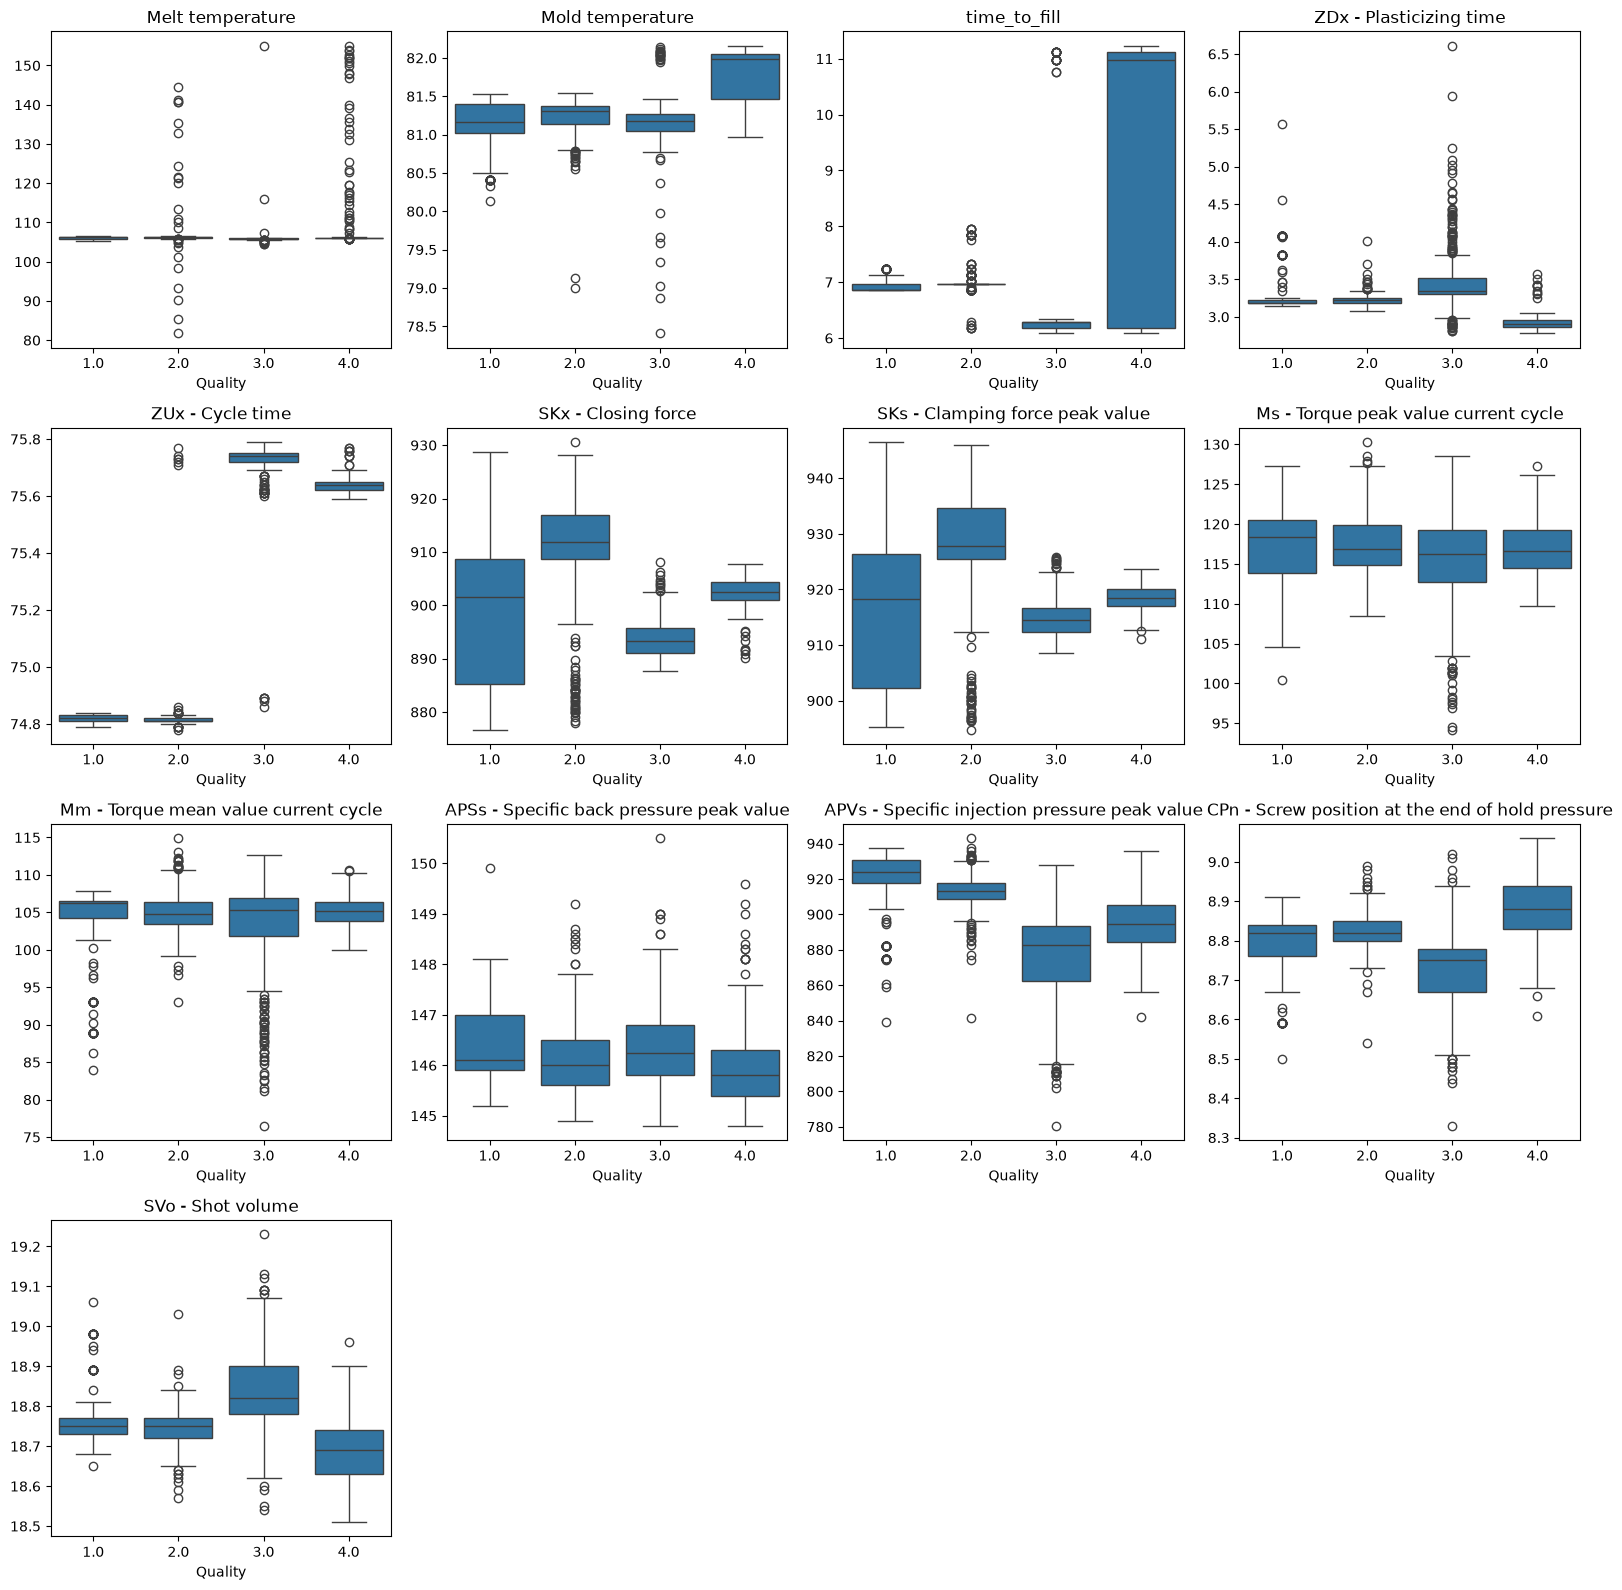

In [10]:
process_columns = df.columns.drop("quality")

fig, axes = plt.subplots(4, 4, figsize=(16, 16))

axes = axes.flatten()

for i, column in enumerate(process_columns):
    sns.boxplot(
        data=df,
        x="quality",
        y=column,
        ax=axes[i]
    )

    axes[i].set_title(column)
    axes[i].set_xlabel("Quality")
    axes[i].set_ylabel("")

for i in range(len(process_columns), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [11]:
spearman_quality = (
    df.corr(method="spearman")["quality"]
    .drop("quality")
    .sort_values(ascending=False)
)

spearman_quality

ZUx - Cycle time                                    0.668619
Mold temperature                                    0.483626
CPn - Screw position at the end of hold pressure    0.219328
Mm - Torque mean value current cycle               -0.027230
time_to_fill                                       -0.027359
SKs - Clamping force peak value                    -0.110969
SKx - Closing force                                -0.119500
Ms - Torque peak value current cycle               -0.129110
Melt temperature                                   -0.133475
SVo - Shot volume                                  -0.192662
APSs - Specific back pressure peak value           -0.245683
ZDx - Plasticizing time                            -0.374940
APVs - Specific injection pressure peak value      -0.582184
Name: quality, dtype: float64

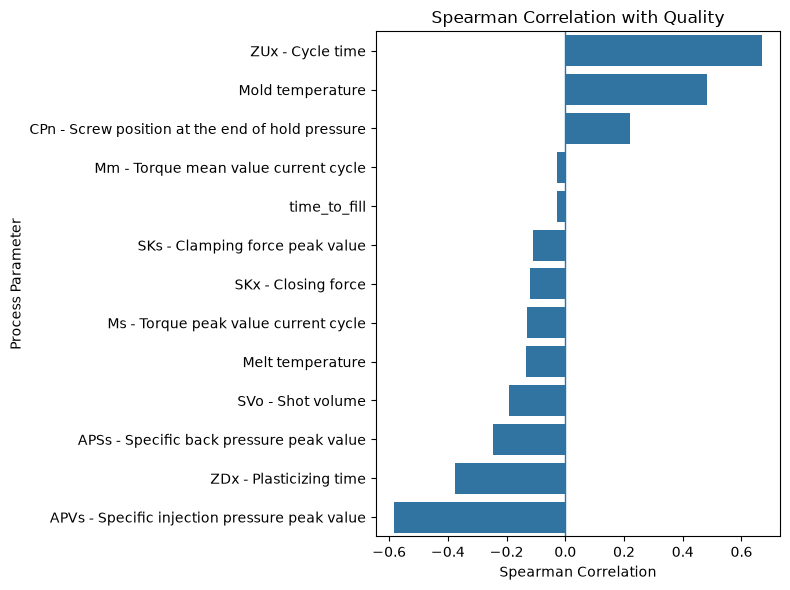

In [12]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=spearman_quality.values,
    y=spearman_quality.index
)

plt.title("Spearman Correlation with Quality")
plt.xlabel("Spearman Correlation")
plt.ylabel("Process Parameter")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

In [13]:
quality_means = df.groupby("quality")[process_columns].mean().T

quality_means

quality,1.0,2.0,3.0,4.0
Melt temperature,106.062991,106.640461,106.020055,108.752877
Mold temperature,81.106881,81.227101,81.151197,81.806685
time_to_fill,6.949168,6.993232,6.543277,9.271814
ZDx - Plasticizing time,3.337285,3.220074,3.490935,2.927260
ZUx - Cycle time,74.819297,74.827266,75.713710,75.638932
SKx - Closing force,898.962118,910.196305,894.246129,902.447945
SKs - Clamping force peak value,915.336839,926.983251,915.032903,918.601096
Ms - Torque peak value current cycle,117.321892,117.353695,115.028387,116.828767
Mm - Torque mean value current cycle,103.283849,105.217734,102.718710,105.111233
APSs - Specific back pressure peak value,146.530000,146.155911,146.330645,145.923014


In [14]:
X = df.drop(columns=["quality"])
y = df["quality"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1451, 13)
Target shape: (1451,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 1160
Test samples: 291


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (1160, 13)
Scaled test shape: (291, 13)


In [17]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [18]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Predictions generated.")
print("First 20 predictions:")
print(y_pred_logistic[:20])

Predictions generated.
First 20 predictions:
[1. 4. 2. 3. 2. 3. 4. 2. 2. 3. 2. 4. 1. 2. 4. 4. 2. 1. 2. 1.]


In [19]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred_logistic)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_logistic
    )
)

Accuracy: 0.8384879725085911

Classification Report:
              precision    recall  f1-score   support

         1.0       0.84      0.64      0.72        74
         2.0       0.73      0.89      0.80        82
         3.0       0.93      0.87      0.90        62
         4.0       0.91      0.96      0.93        73

    accuracy                           0.84       291
   macro avg       0.85      0.84      0.84       291
weighted avg       0.85      0.84      0.84       291


Confusion Matrix:
[[47 27  0  0]
 [ 8 73  1  0]
 [ 1  0 54  7]
 [ 0  0  3 70]]


In [20]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train,
    y_train
)

print("Random Forest training complete.")

Random Forest training complete.


In [21]:
y_pred_rf = random_forest.predict(X_test)

print("Predictions generated.")

Predictions generated.


In [22]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_rf
    )
)

Random Forest Accuracy: 0.9312714776632303

Classification Report:
              precision    recall  f1-score   support

         1.0       0.97      0.92      0.94        74
         2.0       0.93      0.96      0.95        82
         3.0       0.93      0.87      0.90        62
         4.0       0.90      0.96      0.93        73

    accuracy                           0.93       291
   macro avg       0.93      0.93      0.93       291
weighted avg       0.93      0.93      0.93       291


Confusion Matrix:
[[68  6  0  0]
 [ 2 79  1  0]
 [ 0  0 54  8]
 [ 0  0  3 70]]


In [24]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.1


In [25]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train - 1
)

print("XGBoost training complete.")

XGBoost training complete.


In [26]:
y_pred_xgb = xgb_model.predict(X_test)

# Convert predictions back to original quality labels
y_pred_xgb = y_pred_xgb + 1

print("Predictions generated.")

Predictions generated.


In [27]:
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

print("XGBoost Accuracy:", xgb_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_xgb
    )
)

XGBoost Accuracy: 0.9347079037800687

Classification Report:
              precision    recall  f1-score   support

         1.0       0.99      0.92      0.95        74
         2.0       0.93      0.98      0.95        82
         3.0       0.92      0.89      0.90        62
         4.0       0.91      0.95      0.93        73

    accuracy                           0.93       291
   macro avg       0.94      0.93      0.93       291
weighted avg       0.94      0.93      0.93       291


Confusion Matrix:
[[68  6  0  0]
 [ 1 80  1  0]
 [ 0  0 55  7]
 [ 0  0  4 69]]


In [28]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

ZDx - Plasticizing time                             0.218766
ZUx - Cycle time                                    0.156277
time_to_fill                                        0.114941
APVs - Specific injection pressure peak value       0.109774
SKs - Clamping force peak value                     0.092175
SKx - Closing force                                 0.091097
CPn - Screw position at the end of hold pressure    0.056963
Mold temperature                                    0.050695
SVo - Shot volume                                   0.038977
Mm - Torque mean value current cycle                0.020354
Melt temperature                                    0.017992
Ms - Torque peak value current cycle                0.016686
APSs - Specific back pressure peak value            0.015303
dtype: float32

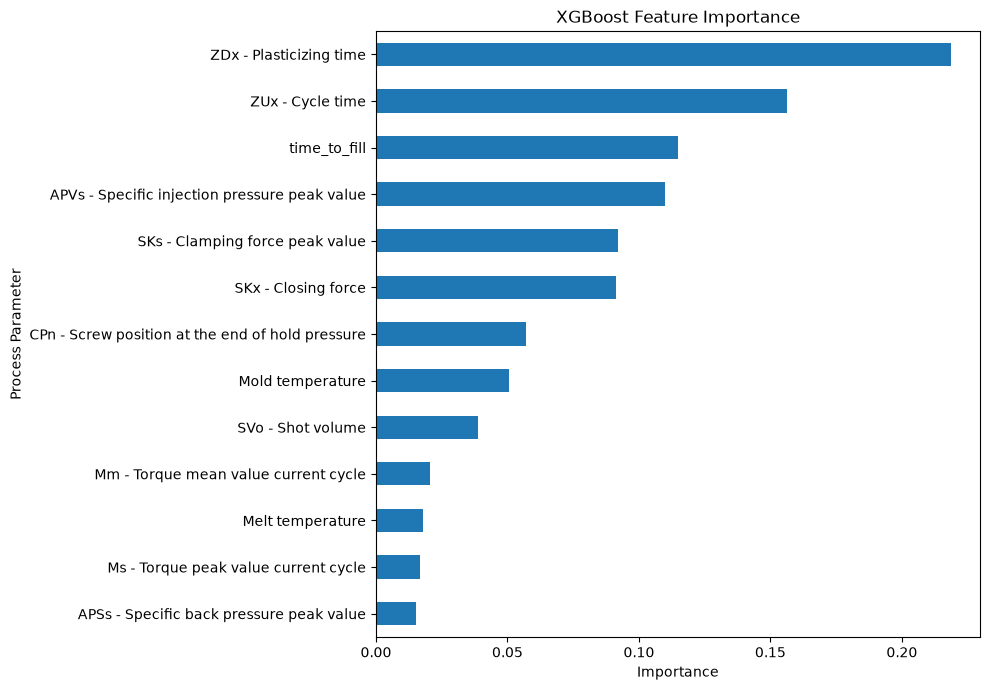

In [29]:
plt.figure(figsize=(10, 7))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Process Parameter")

plt.tight_layout()
plt.show()

In [30]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [31]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer(X_test)

print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (291, 13, 4)


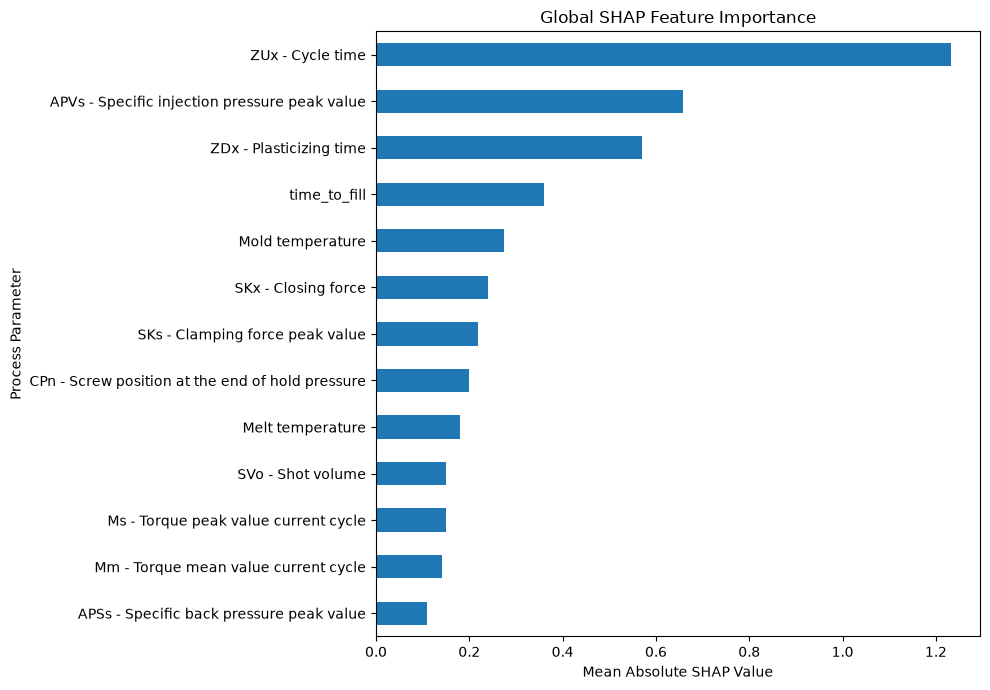

In [33]:
# Mean absolute SHAP contribution across samples and quality classes
global_shap_importance = np.abs(shap_values.values).mean(axis=(0, 2))

global_shap = pd.Series(
    global_shap_importance,
    index=X_test.columns
).sort_values(ascending=True)

global_shap

plt.figure(figsize=(10, 7))

global_shap.plot(kind="barh")

plt.title("Global SHAP Feature Importance")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Process Parameter")

plt.tight_layout()
plt.show()

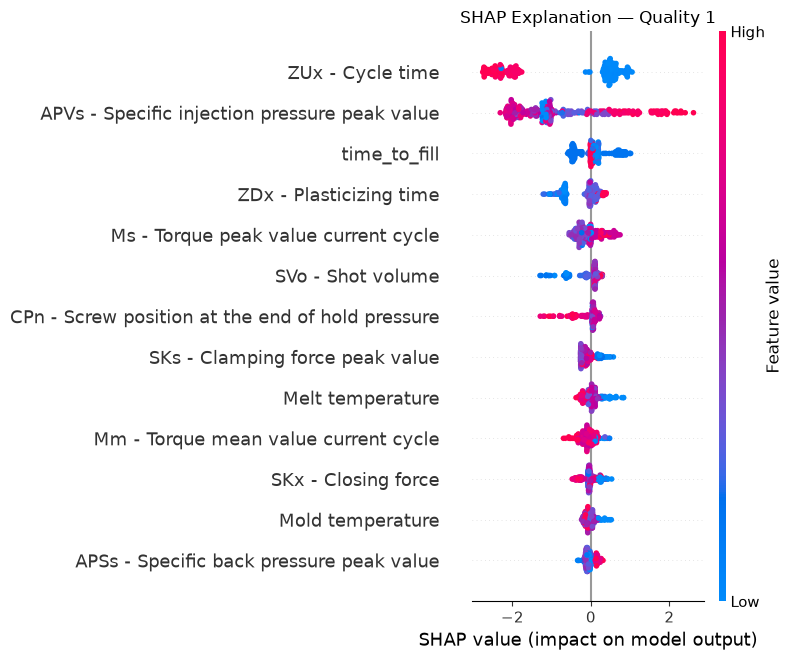

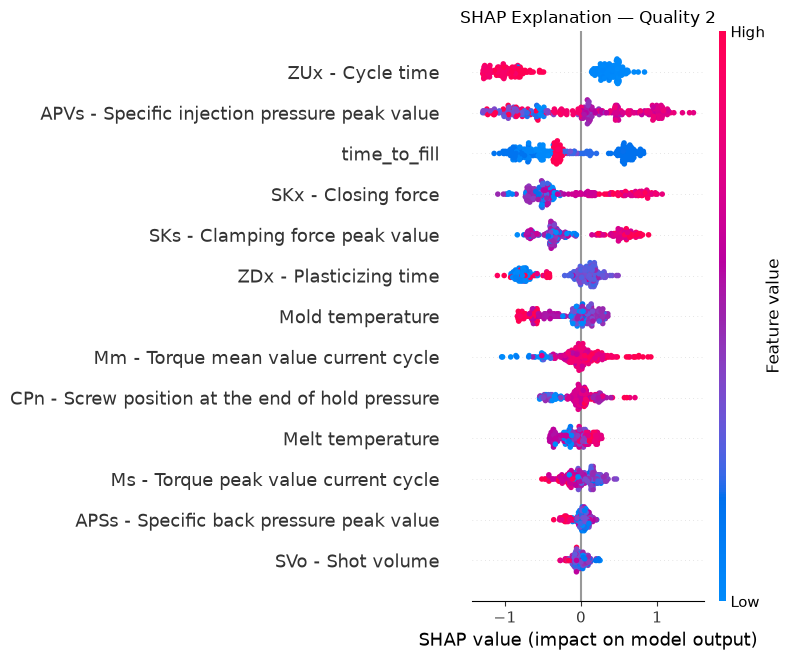

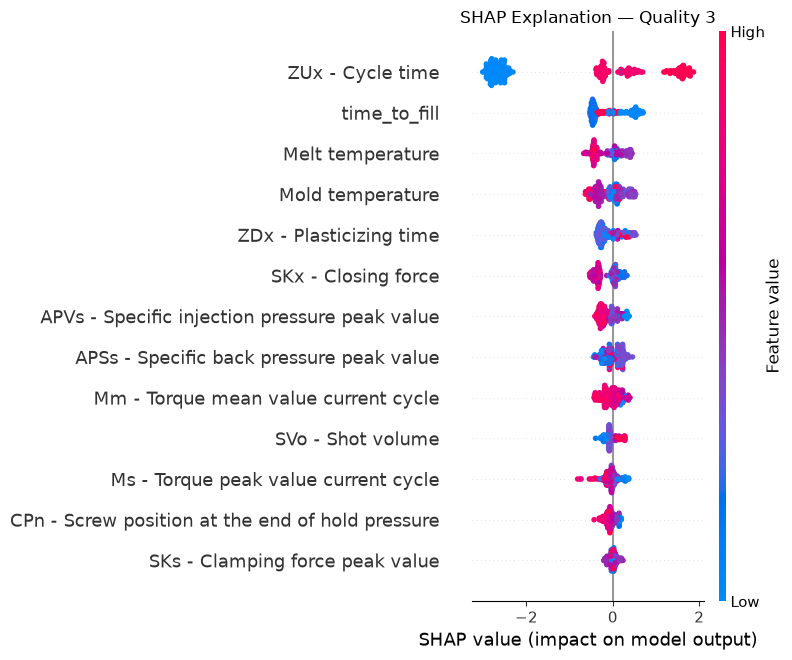

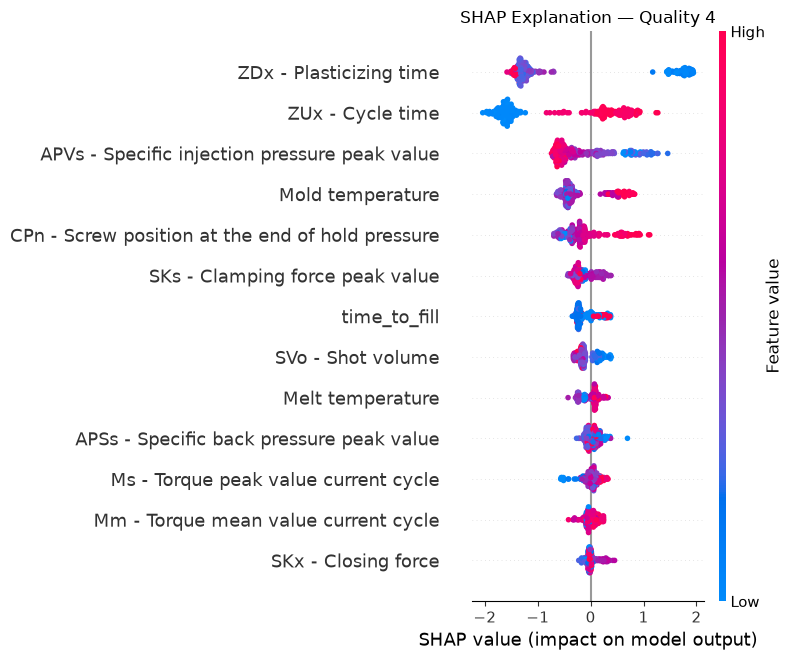

In [34]:
quality_1_shap = shap_values.values[:, :, 0]

shap.summary_plot(
    quality_1_shap,
    X_test,
    show=False
)

plt.title("SHAP Explanation — Quality 1")
plt.tight_layout()
plt.show()

quality_2_shap = shap_values.values[:, :, 1]

shap.summary_plot(
    quality_2_shap,
    X_test,
    show=False
)

plt.title("SHAP Explanation — Quality 2")
plt.tight_layout()
plt.show()

quality_3_shap = shap_values.values[:, :, 2]

shap.summary_plot(
    quality_3_shap,
    X_test,
    show=False
)

plt.title("SHAP Explanation — Quality 3")
plt.tight_layout()
plt.show()

quality_4_shap = shap_values.values[:, :, 3]

shap.summary_plot(
    quality_4_shap,
    X_test,
    show=False
)

plt.title("SHAP Explanation — Quality 4")
plt.tight_layout()
plt.show()

In [35]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.838488
1,Random Forest,0.931271
2,XGBoost,0.934708


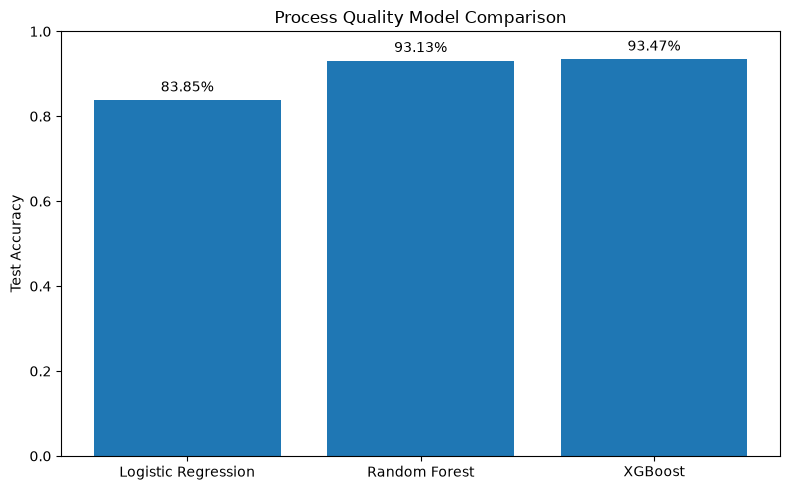

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"]
)

plt.ylim(0, 1)

plt.ylabel("Test Accuracy")
plt.title("Process Quality Model Comparison")

for i, value in enumerate(model_comparison["Accuracy"]):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2%}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [37]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "process_quality_xgb.json"

xgb_model.save_model(model_path)

print("Model saved to:", model_path)

Model saved to: c:\Users\Srushti\Desktop\Foundry quality intelligence\models\process_quality_xgb.json


In [38]:
from xgboost import XGBClassifier

loaded_xgb = XGBClassifier()
loaded_xgb.load_model(model_path)

print("Model loaded successfully.")

Model loaded successfully.
